# 03 · Caracterización del corpus analítico final

Este notebook caracteriza el corpus analítico consolidado que se utilizará como base de los análisis longitudinales y comparativos. No vuelve a limpiar, clasificar ni deduplicar los documentos, sino que parte del artefacto
`outputs/analysis/2015_2025/articles.parquet` generado por el pipeline.

Se distinguen dos conjuntos: el corpus analítico consolidado y el subconjunto elegible para análisis textual (`analysis_eligible == True`). El primero se utiliza para describir la composición y cobertura documental; el segundo, para los análisis que requieren contenido textual suficiente.

El propósito es documentar la transición hacia estos conjuntos, comprobar su integridad y describir su composición por país, medio, año, modalidad de reconocimiento y longitud textual. El análisis sustantivo de la evolución discursiva se reserva para el Notebook 04.

## 1. Configuración

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate
    raise RuntimeError("No se pudo localizar la raíz del repositorio.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

START_YEAR, END_YEAR = 2015, 2025
CORPUS_PATH = ROOT / "outputs" / "analysis" / "2015_2025" / "articles.parquet"
FIGURES_DIR = ROOT / "outputs" / "reports" / \
    "figures" / "03_caracterizacion_corpus_final"
TABLES_DIR = ROOT / "outputs" / "reports" / \
    "tables" / "03_caracterizacion_corpus_final"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = ROOT / "outputs" / "reports"
FINAL_DIR = ROOT / "outputs" / "final"
RUNS_DIR = ROOT / "data" / "runs"
EVIDENCE_DIR = ROOT / "docs" / "evidence"

PHASE1_DIR = REPORTS_DIR / "phase1"
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

CONTEXTUAL_PATH = REPORTS_DIR / "articles_contextual_unique.parquet"
# ==========================================================
# Rutas de entrada
# ==========================================================

# Universo preseleccionado/contextual consolidado
PRESELECTED_CASES_PATH = (
    ROOT
    / "outputs"
    / "reports"
    / "articles_contextual_unique.parquet"
)

# Corpus principal antes de la normalización analítica
MAIN_CASES_PATH = (
    ROOT
    / "outputs"
    / "final"
    / "case_articles_main.parquet"
)

# Conjunto de sensibilidad: evidencia contextual media
MEDIUM_CASES_PATH = (
    ROOT
    / "outputs"
    / "final"
    / "case_articles_sensitivity_medium.parquet"
)

# Casos ambiguos
AMBIGUOUS_CASES_PATH = (
    ROOT
    / "outputs"
    / "final"
    / "case_articles_ambiguous.parquet"
)

# Corpus analítico canónico
ANALYSIS_CORPUS_PATH = (
    ROOT
    / "outputs"
    / "analysis"
    / "2015_2025"
    / "articles.parquet"
)
ANALYSIS_PATH = (
    ROOT
    / "outputs"
    / "analysis"
    / "2015_2025"
    / "articles.parquet"
)
EXTRACTION_SUMMARY_PATH = EVIDENCE_DIR / "extraction_summary.csv"

In [2]:
from src.visualization.palette import COLORS

In [3]:
SOURCE_COLORS = {
    "Argentina": [
        "#B9DFF1",
        COLORS["argentina"],
        COLORS["argentina_dark"],
    ],
    "México": [
        "#9ACBAD",
        COLORS["mexico"],
        COLORS["mexico_dark"],
    ],
}

COUNTRY_COLORS = {
    "Argentina": COLORS["argentina"],
    "México": COLORS["mexico_dark"],
}

PRESELECTION_COLOR = COLORS["violet_300"]
GRID_COLOR = COLORS["grid"]
TEXT_COLOR = COLORS["text"]

RECOGNITION_LABELS = {
    "explicit_femicide_feminicide": "Femicidio/feminicidio explícito",
    "contextual_without_explicit_label": "Reconocimiento contextual",
    "explicit_gender_violence": "Marco de género",
}
RECOGNITION_ORDER = list(RECOGNITION_LABELS.values())

RECOGNITION_COLORS = {
    "Femicidio/feminicidio explícito": COLORS["violet_500"],
    "Reconocimiento contextual": COLORS["violet_400"],
    "Marco de género": COLORS["secondary_300"],
}

SOURCE_LABELS = {
    "clarin_arg": "Clarín", "lanacion": "La Nación", "pagina12": "Página/12",
    "eluniversal_mx": "El Universal", "milenio": "Milenio", "jornada": "La Jornada",
}
SOURCE_ORDER = {
    "Argentina": ["Clarín", "La Nación", "Página/12"],
    "México": ["El Universal", "Milenio", "La Jornada"],
}

In [4]:

def fmt_int(v): return f"{int(round(v)):,}".replace(",", ".")
def fmt_pct(v, d=1): return f"{v:.{d}f}%".replace(".", ",")


def assert_columns(df, cols, name="DataFrame"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Faltan columnas en {name}: {missing}")


def save_figure(fig, name):
    p = FIGURES_DIR/name
    fig.savefig(p, dpi=300, bbox_inches="tight")
    print("Figura:", p.relative_to(ROOT))


def save_table(df, name):
    p = TABLES_DIR/name
    df.to_csv(p, encoding="utf-8-sig")
    print("Tabla:", p.relative_to(ROOT))


def add_source_labels(df):
    out = df.copy()
    out["newspaper"] = out["source"].map(SOURCE_LABELS).fillna(out["source"])
    out["country"] = out["country"].astype("string").replace(
        {"MΘxico": "México", "Mexico": "México"})
    return out


def label_bars(ax, bars, pct=False, fontsize=8):
    for b in bars:
        v = b.get_height()
        if pd.notna(v) and v > 0:
            ax.text(b.get_x()+b.get_width()/2, v, fmt_pct(v) if pct else fmt_int(v),
                    ha="center", va="bottom", fontsize=fontsize, color=COLORS["text"])


def clean_axes(ax):
    ax.grid(axis="y", alpha=.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## 2. Del universo contextual al corpus analítico

A partir del universo contextual consolidado se reconstruye la preselección temática mediante los estados definidos por el pipeline. Posteriormente se documenta su distribución entre el corpus principal, los conjuntos de revisión y sensibilidad y, finalmente, el corpus analítico consolidado.

### 2.1 Carga del universo contextual y conjuntos finales

In [5]:
# ------------------------------------------------------------
# 2.1 Carga del universo contextual y conjuntos finales
# ------------------------------------------------------------

contextual_universe = pd.read_parquet(
    PRESELECTED_CASES_PATH
)

main_cases = pd.read_parquet(
    MAIN_CASES_PATH
)

medium_cases = pd.read_parquet(
    MEDIUM_CASES_PATH
)

ambiguous_cases = pd.read_parquet(
    AMBIGUOUS_CASES_PATH
)


# ------------------------------------------------------------
# 2.2 Reconstrucción de la preselección temática
# ------------------------------------------------------------

SELECTED_STATUSES = {
    "candidate_explicit_case",
    "candidate_contextual_high",
    "review_contextual_medium",
    "review_ambiguous_case",
}

preselected_cases = (
    contextual_universe.loc[
        contextual_universe[
            "provisional_case_status"
        ].isin(SELECTED_STATUSES)
    ]
    .copy()
)


# ------------------------------------------------------------
# 2.3 Resumen de los conjuntos
# ------------------------------------------------------------

datasets_transition = pd.DataFrame({
    "Conjunto": [
        "Universo contextual",
        "Preselección temática",
        "Corpus principal",
        "Sensibilidad media",
        "Casos ambiguos",
    ],
    "Documentos": [
        len(contextual_universe),
        len(preselected_cases),
        len(main_cases),
        len(medium_cases),
        len(ambiguous_cases),
    ],
})

datasets_transition["Porcentaje_sobre_universo"] = (
    100
    * datasets_transition["Documentos"]
    / len(contextual_universe)
)

display(datasets_transition)

,Conjunto,Documentos,Porcentaje_sobre_universo
0,Universo contextual,408074,100.00
1,Preselección temática,5413,1.33
2,Corpus principal,3548,0.87
3,Sensibilidad media,196,0.05
4,Casos ambiguos,1607,0.39


### 2.2 Carga del corpus analítico consolidado

Se reconcilian las noticias preseleccionadas con los tres destinos generados por el pipeline:

- corpus principal;
- sensibilidad media;
- casos ambiguos.

Las noticias que no aparecen en ninguno de esos tres conjuntos se contabilizan como exclusiones durante la consolidación final.

In [6]:
# ------------------------------------------------------------
# 2.2.1 Carga del corpus analítico consolidado
# ------------------------------------------------------------

if not CORPUS_PATH.exists():
    raise FileNotFoundError(
        f"No existe {CORPUS_PATH}"
    )

articles_all = pd.read_parquet(
    CORPUS_PATH
)

required = [
    "source",
    "country",
    "analysis_identity",
    "analysis_text",
    "analysis_text_length",
    "analysis_eligible",
    "analysis_year",
    "analysis_year_source",
    "analysis_period",
    "gender_recognition_mode",
    "explicit_label_type",
    "word_count",
    "title_word_count",
]

assert_columns(
    articles_all,
    required,
    "articles_all",
)

articles_all = add_source_labels(
    articles_all
)


# ------------------------------------------------------------
# 2.2.2 Corpus elegible para análisis textual
# ------------------------------------------------------------

analysis_corpus = (
    articles_all.loc[
        articles_all[
            "analysis_eligible"
        ].eq(True)
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2.2.3 Transición entre conjuntos
# ------------------------------------------------------------

n_main = len(main_cases)
n_analytical = len(articles_all)
n_eligible = len(analysis_corpus)

transition = pd.DataFrame({
    "Etapa": [
        "Corpus principal",
        "Corpus analítico consolidado",
        "Corpus elegible para análisis textual",
    ],
    "Documentos": [
        n_main,
        n_analytical,
        n_eligible,
    ],
})

transition["Cambio_vs_anterior"] = (
    transition["Documentos"]
    .diff()
    .astype("Int64")
)

transition["Reduccion_vs_anterior_pct"] = (
    100
    * (
        transition["Documentos"].shift(1)
        - transition["Documentos"]
    )
    / transition["Documentos"].shift(1)
)

display(
    transition
)

save_table(
    transition,
    "03_transicion_corpus_analitico.csv",
)


print(
    f"Corpus principal: "
    f"{n_main:,}"
)

print(
    f"Corpus analítico consolidado: "
    f"{n_analytical:,}"
)

print(
    f"Corpus elegible para análisis textual: "
    f"{n_eligible:,}"
)

print(
    "\nCorpus utilizado desde este punto para "
    f"análisis textuales: {n_eligible:,} artículos"
)

,Etapa,Documentos,Cambio_vs_anterior,Reduccion_vs_anterior_pct
0,Corpus principal,3548,<NA>,NaN
1,Corpus analítico consolidado,3497,-51,1.44
2,Corpus elegible para análisis textual,3419,-78,2.23


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\03_transicion_corpus_analitico.csv
Corpus principal: 3,548
Corpus analítico consolidado: 3,497
Corpus elegible para análisis textual: 3,419

Corpus utilizado desde este punto para análisis textuales: 3,419 artículos


Figura: outputs\reports\figures\03_caracterizacion_corpus_final\01_transicion_corpus_analitico.png


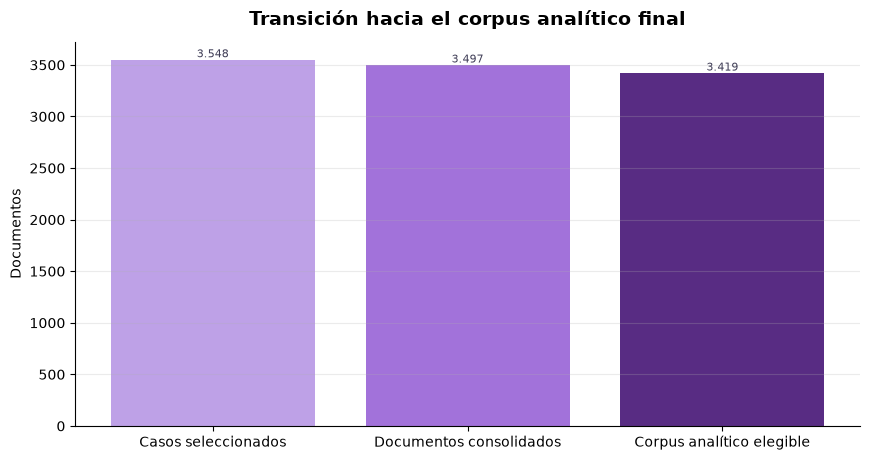

In [7]:
fig, ax = plt.subplots(figsize=(8.8, 4.7))
bars = ax.bar(["Casos seleccionados", "Documentos consolidados", "Corpus analítico elegible"],
              transition["Documentos"], color=[COLORS["violet_300"], COLORS["violet_400"], COLORS["violet_main"]])
label_bars(ax, bars)
ax.set_title("Transición hacia el corpus analítico final",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Documentos")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "01_transicion_corpus_analitico.png")
plt.show()

## 3. Controles de integridad

Los controles siguientes no modifican el corpus. Verifican que el resultado del pipeline contiene una identidad documental única, texto suficiente y un año analítico válido para todos los documentos elegibles.

In [8]:
checks = pd.DataFrame({
    "Control": ["Todos elegibles", "Identidad analítica única", "Texto no vacío", "Texto >= 200 caracteres",
                "Año analítico disponible", "Año dentro de 2015–2025"],
    "Resultado": [
        bool(analysis_corpus["analysis_eligible"].all()),
        bool(analysis_corpus["analysis_identity"].is_unique),
        bool(analysis_corpus["analysis_text"].fillna(
            "").astype(str).str.strip().ne("").all()),
        bool(analysis_corpus["analysis_text_length"].ge(200).all()),
        bool(analysis_corpus["analysis_year"].notna().all()),
        bool(analysis_corpus["analysis_year"].between(
            START_YEAR, END_YEAR).all()),
    ]})
display(checks)
assert checks["Resultado"].all(), "Falló al menos un control de integridad."

,Control,Resultado
0,Todos elegibles,True
1,Identidad analítica única,True
2,Texto no vacío,True
3,Texto >= 200 caracteres,True
4,Año analítico disponible,True
5,Año dentro de 2015–2025,True


## 4. Composición del corpus

Los recuentos absolutos describen el volumen documental disponible. Como la cobertura no es uniforme, se incluye también la contribución porcentual de cada medio dentro de su país. Estas diferencias deberán considerarse en el análisis comparativo posterior.

### 4.1 Distribución por categoría

In [9]:
final_corpus_composition = (
    analysis_corpus[
        "gender_recognition_mode"
    ]
    .value_counts()
    .rename_axis("gender_recognition_mode")
    .reset_index(name="Noticias")
)

final_corpus_composition["Categoría"] = (
    final_corpus_composition[
        "gender_recognition_mode"
    ]
    .map(RECOGNITION_LABELS)
)

# Control: no debe haber categorías sin mapear.
unmapped = final_corpus_composition.loc[
    final_corpus_composition["Categoría"].isna(),
    "gender_recognition_mode",
].tolist()

if unmapped:
    raise ValueError(
        "Hay valores de gender_recognition_mode "
        f"sin categoría definida: {unmapped}"
    )

final_corpus_composition["Porcentaje"] = (
    100
    * final_corpus_composition["Noticias"]
    / len(analysis_corpus)
)

final_corpus_composition = (
    final_corpus_composition[
        [
            "Categoría",
            "Noticias",
            "Porcentaje",
        ]
    ]
    .sort_values(
        "Noticias",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(final_corpus_composition)

print(
    f"Total corpus final de análisis: "
    f"{len(analysis_corpus):,}"
)

save_table(
    final_corpus_composition,
    "02_composicion_corpus_final.csv",
)

,Categoría,Noticias,Porcentaje
0,Femicidio/feminicidio explícito,2963,86.66
1,Reconocimiento contextual,338,9.89
2,Marco de género,118,3.45


Total corpus final de análisis: 3,419
Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\02_composicion_corpus_final.csv


Figura: outputs\reports\figures\03_caracterizacion_corpus_final\02_composicion_corpus_principal.png


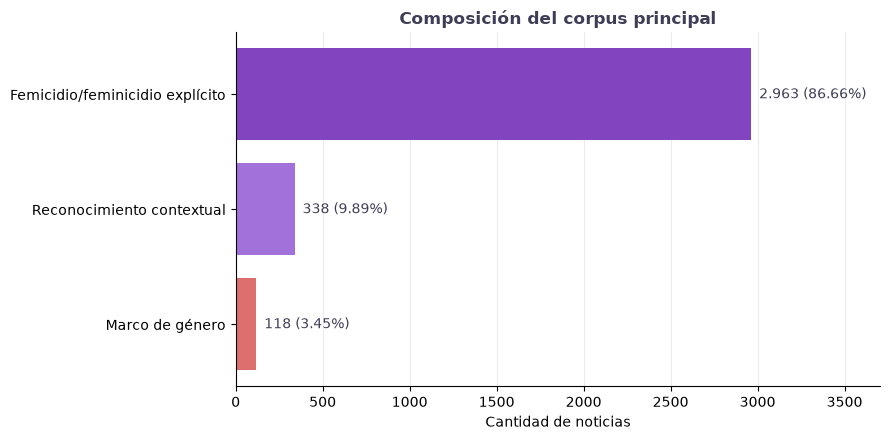

In [10]:
# ------------------------------------------------------------
# Gráfico: composición del corpus principal
# ------------------------------------------------------------

plot_data = (
    final_corpus_composition
    .sort_values(
        "Noticias",
        ascending=True,
    )
)

bar_colors = [
    RECOGNITION_COLORS[category]
    for category in plot_data["Categoría"]
]

fig, ax = plt.subplots(
    figsize=(9, 4.5)
)

bars = ax.barh(
    plot_data["Categoría"],
    plot_data["Noticias"],
    color=bar_colors,
)

for bar, (_, row) in zip(
    bars,
    plot_data.iterrows(),
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        (
            f"  {fmt_int(row['Noticias'])} "
            f"({row['Porcentaje']:.2f}%)"
        ),
        va="center",
        fontsize=10,
        color=COLORS["text"],
    )

ax.set_title(
    "Composición del corpus principal",
    fontweight="bold",
    color=COLORS["text"],
)

ax.set_xlabel(
    "Cantidad de noticias"
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    color=COLORS["grid"],
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(
    0,
    plot_data["Noticias"].max() * 1.25,
)

plt.tight_layout()

save_figure(
    fig,
    "02_composicion_corpus_principal.png",
)

plt.show()

### 4.2 Distribución general por país

In [11]:
country_summary = (
    analysis_corpus
    .groupby("country", as_index=False)
    .size()
    .rename(columns={"size": "Documentos"})
)

country_summary["Porcentaje"] = (
    100
    * country_summary["Documentos"]
    / len(analysis_corpus)
)

country_summary = (
    country_summary
    .sort_values(
        "Documentos",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(country_summary)

# Control
assert country_summary["Documentos"].sum() == len(analysis_corpus)
assert np.isclose(
    country_summary["Porcentaje"].sum(),
    100.0,
)

save_table(
    country_summary,
    "04_composicion_por_pais.csv",
)

,country,Documentos,Porcentaje
0,México,2219,64.90
1,Argentina,1200,35.10


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\04_composicion_por_pais.csv


Figura: outputs\reports\figures\03_caracterizacion_corpus_final\02_corpus_por_pais.png


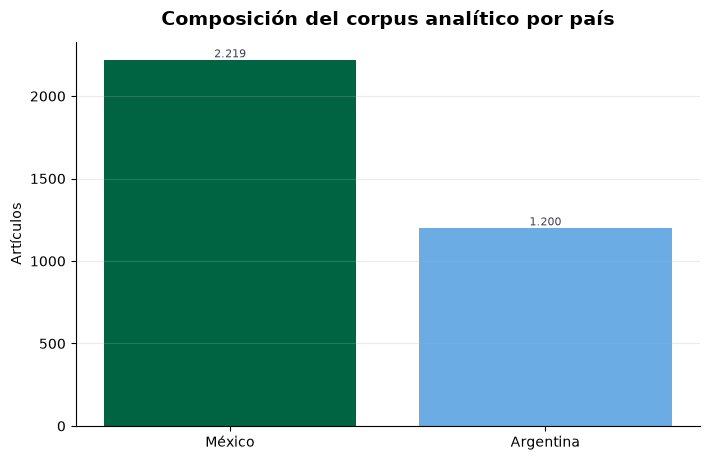

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.7))
bars = ax.bar(country_summary["country"], country_summary["Documentos"],
              color=[COUNTRY_COLORS.get(x, COLORS["quinary_500"]) for x in country_summary["country"]])
label_bars(ax, bars)
ax.set_title("Composición del corpus analítico por país",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Artículos")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "02_corpus_por_pais.png")
plt.show()

### 4.3 Distribución anual por país

country,Argentina,México
analysis_year,,
2015,112,56
2016,229,49
2017,100,99
2018,66,66
2019,63,33
2020,51,80
2021,50,454
2022,31,697
2023,216,239


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\04_corpus_anio_pais.csv
Figura: outputs\reports\figures\03_caracterizacion_corpus_final\06_corpus_anio_pais.png


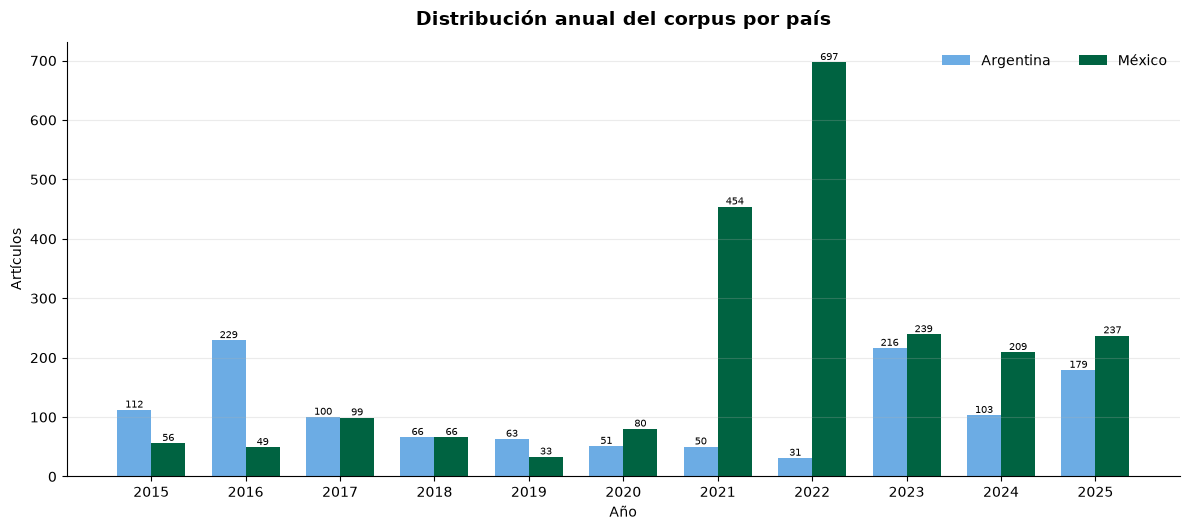

In [13]:
yc = analysis_corpus.groupby(["analysis_year", "country"], as_index=False).size().rename(
    columns={"size": "Documentos"})
yct = yc.pivot(index="analysis_year", columns="country", values="Documentos").reindex(
    range(START_YEAR, END_YEAR+1)).fillna(0).astype(int)
display(yct)
save_table(yct, "04_corpus_anio_pais.csv")

years = list(range(START_YEAR, END_YEAR+1))
x = np.arange(len(years))
width = .36
fig, ax = plt.subplots(figsize=(12, 5.4))
for off, country in [(-width/2, "Argentina"), (width/2, "México")]:
    vals = yct[country].reindex(years).fillna(0).to_numpy()
    bars = ax.bar(x+off, vals, width=width, label=country,
                  color=COUNTRY_COLORS[country])
    for b in bars:
        if b.get_height() > 0:
            ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                    fmt_int(b.get_height()), ha="center", va="bottom", fontsize=7)
ax.set_title("Distribución anual del corpus por país",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Año")
ax.set_ylabel("Artículos")
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend(frameon=False, ncol=2)
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "06_corpus_anio_pais.png")
plt.show()

Figura: outputs\reports\figures\03_caracterizacion_corpus_final\06_corpus_anio_pais_heatmap.png


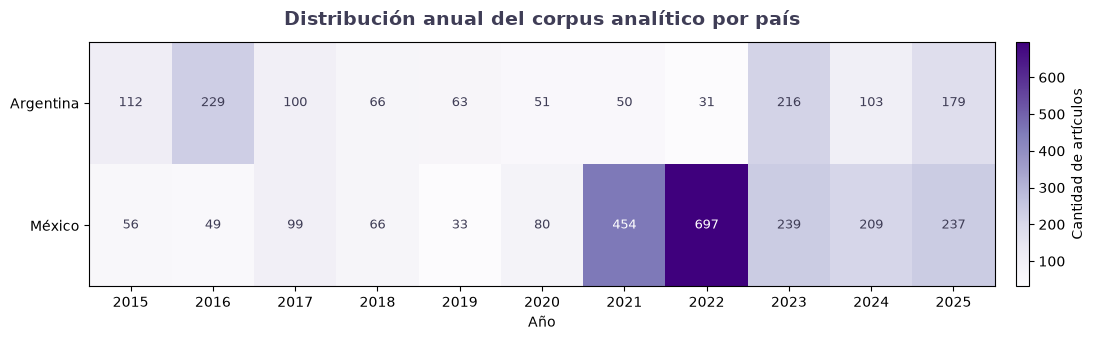

In [14]:
# ------------------------------------------------------------
# Heatmap: distribución anual por país
# ------------------------------------------------------------

heatmap_data = yct.T

fig, ax = plt.subplots(
    figsize=(12, 3.5)
)

im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Purples",
)

# ------------------------------------------------------------
# Ejes
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(len(heatmap_data.columns))
)

ax.set_xticklabels(
    heatmap_data.columns.astype(int)
)

ax.set_yticks(
    np.arange(len(heatmap_data.index))
)

ax.set_yticklabels(
    heatmap_data.index
)

ax.set_xlabel("Año")
ax.set_ylabel("")

ax.set_title(
    "Distribución anual del corpus analítico por país",
    fontsize=14,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

# ------------------------------------------------------------
# Valores dentro de las celdas
# ------------------------------------------------------------

threshold = (
    heatmap_data.values.max() / 2
)

for i in range(
    heatmap_data.shape[0]
):
    for j in range(
        heatmap_data.shape[1]
    ):

        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            fmt_int(value),
            ha="center",
            va="center",
            fontsize=9,
            color=(
                "white"
                if value > threshold
                else TEXT_COLOR
            ),
        )

# ------------------------------------------------------------
# Barra de color
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Cantidad de artículos"
)

plt.tight_layout()

save_figure(
    fig,
    "06_corpus_anio_pais_heatmap.png",
)

plt.show()

### 4.4 Composición anual de categorías del corpus principal por país

In [15]:
# ------------------------------------------------------------
# Construir dataset para el gráfico
# ------------------------------------------------------------

final_category_year_country = (
    main_cases
    .assign(
        final_category=lambda df:
            df["gender_recognition_mode"]
            .map(RECOGNITION_LABELS),

        year=lambda df:
            pd.to_numeric(
                df["archive_year"],
                errors="coerce",
            ),
    )
    .dropna(
        subset=[
            "country",
            "year",
            "final_category",
        ]
    )
    .groupby(
        [
            "country",
            "year",
            "final_category",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "Noticias",
        }
    )
)

final_category_year_country["year"] = (
    final_category_year_country["year"]
    .astype(int)
)

display(
    final_category_year_country
)

,country,year,final_category,Noticias
0,Argentina,2015,Femicidio/feminicidio explícito,74
1,Argentina,2015,Marco de género,12
2,Argentina,2015,Reconocimiento contextual,26
3,Argentina,2016,Femicidio/feminicidio explícito,180
4,Argentina,2016,Marco de género,15
5,Argentina,2016,Reconocimiento contextual,35
6,Argentina,2017,Femicidio/feminicidio explícito,83
7,Argentina,2017,Marco de género,9
8,Argentina,2017,Reconocimiento contextual,16
9,Argentina,2018,Femicidio/feminicidio explícito,47


Figura: outputs\reports\figures\03_caracterizacion_corpus_final\05_composicion_anual_corpus_principal_pais.png


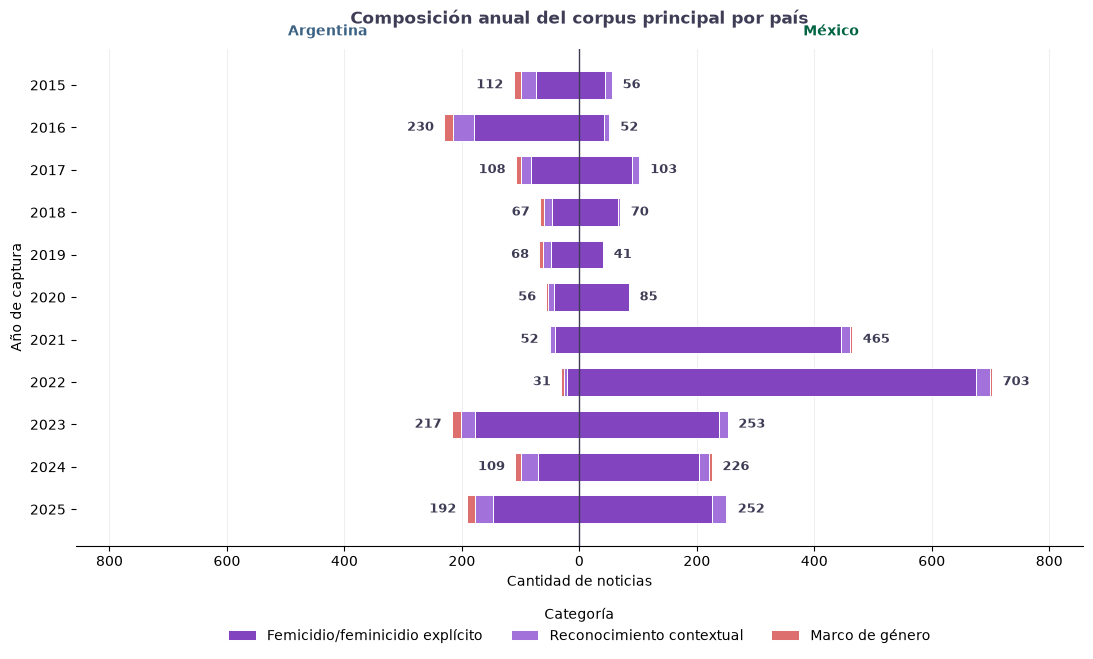

In [16]:
# ------------------------------------------------------------
# Back-to-back Argentina vs México
# ------------------------------------------------------------

plot_base = (
    final_category_year_country
    .pivot_table(
        index=[
            "country",
            "year",
        ],
        columns="final_category",
        values="Noticias",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(
        columns=RECOGNITION_ORDER,
        fill_value=0,
    )
)

years = list(
    range(
        START_YEAR,
        END_YEAR + 1,
    )
)


def country_matrix(country):

    countries = (
        plot_base.index
        .get_level_values("country")
    )

    if country in countries:

        return (
            plot_base
            .loc[country]
            .reindex(
                years,
                fill_value=0,
            )
        )

    return pd.DataFrame(
        0,
        index=years,
        columns=RECOGNITION_ORDER,
    )


arg = country_matrix(
    "Argentina"
)

mx = country_matrix(
    "México"
)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 7)
)

y = np.arange(
    len(years)
)

arg_left = np.zeros(
    len(years)
)

mx_left = np.zeros(
    len(years)
)


for category in RECOGNITION_ORDER:

    arg_values = (
        arg[category]
        .to_numpy()
    )

    mx_values = (
        mx[category]
        .to_numpy()
    )

    # Argentina
    ax.barh(
        y,
        -arg_values,
        left=-arg_left,
        height=0.65,
        color=RECOGNITION_COLORS[category],
        edgecolor="white",
        linewidth=0.7,
        label=category,
    )

    # México
    ax.barh(
        y,
        mx_values,
        left=mx_left,
        height=0.65,
        color=RECOGNITION_COLORS[category],
        edgecolor="white",
        linewidth=0.7,
    )

    arg_left += arg_values
    mx_left += mx_values


# ------------------------------------------------------------
# Totales
# ------------------------------------------------------------

max_total = max(
    arg_left.max()
    if len(arg_left)
    else 0,

    mx_left.max()
    if len(mx_left)
    else 0,
)

offset = (
    max_total * 0.025
    if max_total
    else 1
)


for i, (arg_total, mx_total) in enumerate(
    zip(
        arg_left,
        mx_left,
    )
):

    if arg_total > 0:

        ax.text(
            -arg_total - offset,
            i,
            fmt_int(arg_total),
            ha="right",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=TEXT_COLOR,
        )

    if mx_total > 0:

        ax.text(
            mx_total + offset,
            i,
            fmt_int(mx_total),
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=TEXT_COLOR,
        )


# ------------------------------------------------------------
# Formato
# ------------------------------------------------------------

ax.axvline(
    0,
    color=TEXT_COLOR,
    linewidth=1,
)

ax.set_yticks(y)
ax.set_yticklabels(years)

# 2015 arriba -> 2025 abajo
ax.invert_yaxis()

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
            fmt_int(abs(x))
    )
)

if max_total > 0:

    limit = (
        max_total * 1.22
    )

    ax.set_xlim(
        -limit,
        limit,
    )


ax.set_title(
    "Composición anual del corpus principal por país",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=18,
)

ax.set_xlabel(
    "Cantidad de noticias"
)

ax.set_ylabel(
    "Año de captura"
)


# ------------------------------------------------------------
# Encabezados de países
# ------------------------------------------------------------

ax.text(
    0.25,
    1.02,
    "Argentina",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontweight="bold",
    color=COLORS["argentina_dark"],
)

ax.text(
    0.75,
    1.02,
    "México",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontweight="bold",
    color=COLORS["mexico_dark"],
)


ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.7,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.legend(
    title="Categoría",
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.10,
    ),
    ncol=3,
    frameon=False,
)


fig.subplots_adjust(
    bottom=0.17,
    top=0.88,
)

save_figure(
    fig,
    "05_composicion_anual_corpus_principal_pais.png",
)

plt.show()

### 4.5 Distribución general por periódico

In [17]:
# ============================================================
# Composición del corpus analítico por medio
# ============================================================

source_summary = (
    analysis_corpus
    .groupby(
        ["country", "newspaper"],
        as_index=False,
    )
    .size()
    .rename(
        columns={"size": "Documentos"}
    )
)

source_summary["Porcentaje_dentro_pais"] = (
    100
    * source_summary["Documentos"]
    / source_summary
    .groupby("country")["Documentos"]
    .transform("sum")
)

# ------------------------------------------------------------
# Ordenar de mayor a menor
# ------------------------------------------------------------

source_summary = (
    source_summary
    .sort_values(
        "Documentos",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(source_summary)

save_table(
    source_summary.set_index(
        ["country", "newspaper"]
    ),
    "02_corpus_por_medio.csv",
)

,country,newspaper,Documentos,Porcentaje_dentro_pais
0,México,Milenio,1198,53.99
1,México,La Jornada,1017,45.83
2,Argentina,Clarín,667,55.58
3,Argentina,La Nación,363,30.25
4,Argentina,Página/12,170,14.17
5,México,El Universal,4,0.18


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\02_corpus_por_medio.csv


Figura: outputs\reports\figures\03_caracterizacion_corpus_final\03_corpus_por_medio.png


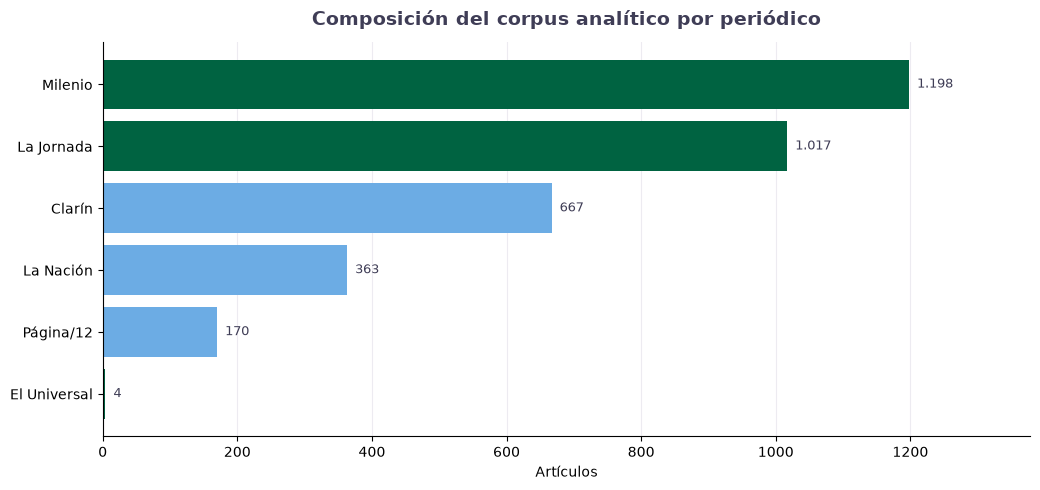

In [18]:
# ------------------------------------------------------------
# Ordenar de mayor a menor
# ------------------------------------------------------------

plot_data = (
    source_summary
    .sort_values(
        "Documentos",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Colores según país
# ------------------------------------------------------------

bar_colors = [
    COLORS["argentina"]
    if country == "Argentina"
    else COLORS["mexico_dark"]
    for country in plot_data["country"]
]


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 5.0)
)

bars = ax.barh(
    plot_data["newspaper"],
    plot_data["Documentos"],
    color=bar_colors,
)

for bar, (_, row) in zip(
    bars,
    plot_data.iterrows(),
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {fmt_int(row['Documentos'])}",
        va="center",
        fontsize=9,
        color=TEXT_COLOR,
    )

# La categoría con mayor cantidad queda arriba
ax.invert_yaxis()

ax.set_title(
    "Composición del corpus analítico por periódico",
    fontsize=14,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_xlabel("Artículos")
ax.set_ylabel("")

ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_documents = plot_data["Documentos"].max()

ax.set_xlim(
    0,
    max_documents * 1.15
    if max_documents > 0
    else 1,
)

plt.tight_layout()

save_figure(
    fig,
    "03_corpus_por_medio.png",
)

plt.show()

Figura: outputs\reports\figures\03_caracterizacion_corpus_final\04_contribucion_medio_dentro_pais.png


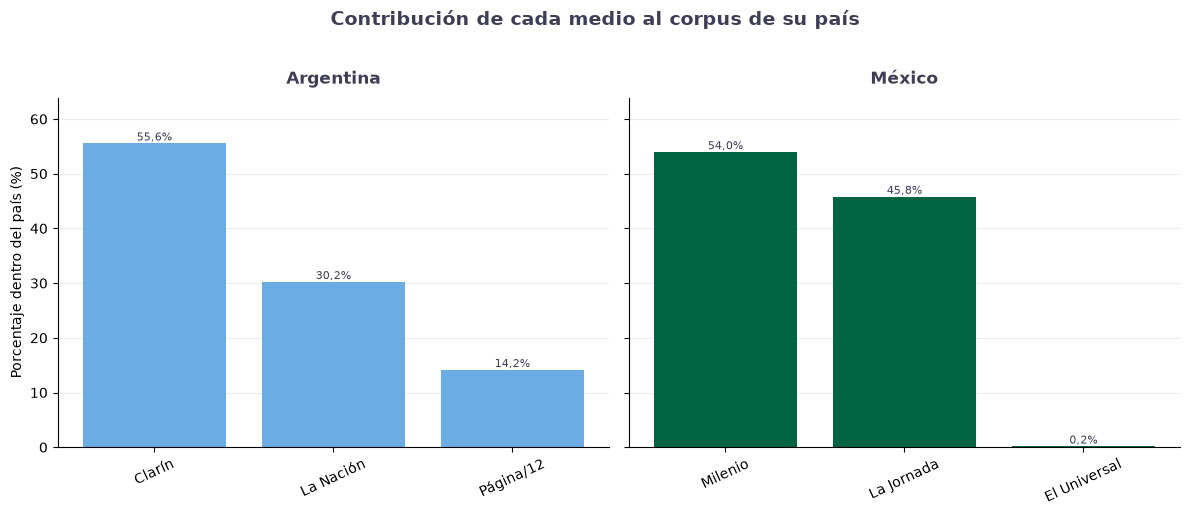

In [19]:
# ============================================================
# Contribución de cada medio al corpus de su país
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharey=True,
)

for ax, country in zip(
    axes,
    ["Argentina", "México"],
):

    # --------------------------------------------------------
    # Datos del país, ordenados de mayor a menor
    # --------------------------------------------------------

    plot_data = (
        source_summary[
            source_summary["country"] == country
        ]
        .sort_values(
            "Porcentaje_dentro_pais",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Gráfico
    # --------------------------------------------------------

    bars = ax.bar(
        plot_data["newspaper"],
        plot_data["Porcentaje_dentro_pais"],
        color=COUNTRY_COLORS[country],
    )

    label_bars(
        ax,
        bars,
        pct=True,
    )

    ax.set_title(
        country,
        fontsize=12,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=10,
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="x",
        rotation=25,
    )

    ax.grid(
        axis="y",
        color=GRID_COLOR,
        linewidth=0.8,
        alpha=0.8,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# Escala común
# ------------------------------------------------------------

max_pct = source_summary[
    "Porcentaje_dentro_pais"
].max()

axes[0].set_ylim(
    0,
    max_pct * 1.15
    if max_pct > 0
    else 1,
)

axes[0].set_ylabel(
    "Porcentaje dentro del país (%)"
)

axes[1].set_ylabel("")


# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------

fig.suptitle(
    "Contribución de cada medio al corpus de su país",
    fontsize=14,
    fontweight="bold",
    color=TEXT_COLOR,
    y=1.02,
)

fig.tight_layout()

save_figure(
    fig,
    "04_contribucion_medio_dentro_pais.png",
)

plt.show()

### 4.6 Cobertura mensual por medio y año

La matriz representa **cobertura documental**, no intensidad de la violencia machista. Los análisis comparativos posteriores deberán emplear proporciones o frecuencias normalizadas cuando los tamaños de los subconjuntos difieran.

analysis_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
newspaper,,,,,,,,,,,
Clarín,11,12,12,12,10,11,11,10,12,9,10
El Universal,3,0,0,0,0,0,0,0,0,0,0
La Jornada,0,0,0,4,1,4,12,8,5,11,4
La Nación,0,0,0,0,0,0,0,2,12,11,12
Milenio,11,11,12,11,8,12,10,12,12,11,12
Página/12,9,11,0,1,0,0,0,0,0,0,2


findfont: Failed to find font weight medium, now using 400.


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\06_matriz_meses_representados_medio_anio.csv
Figura: outputs\reports\figures\03_caracterizacion_corpus_final\08_heatmap_meses_representados_medio_anio.png


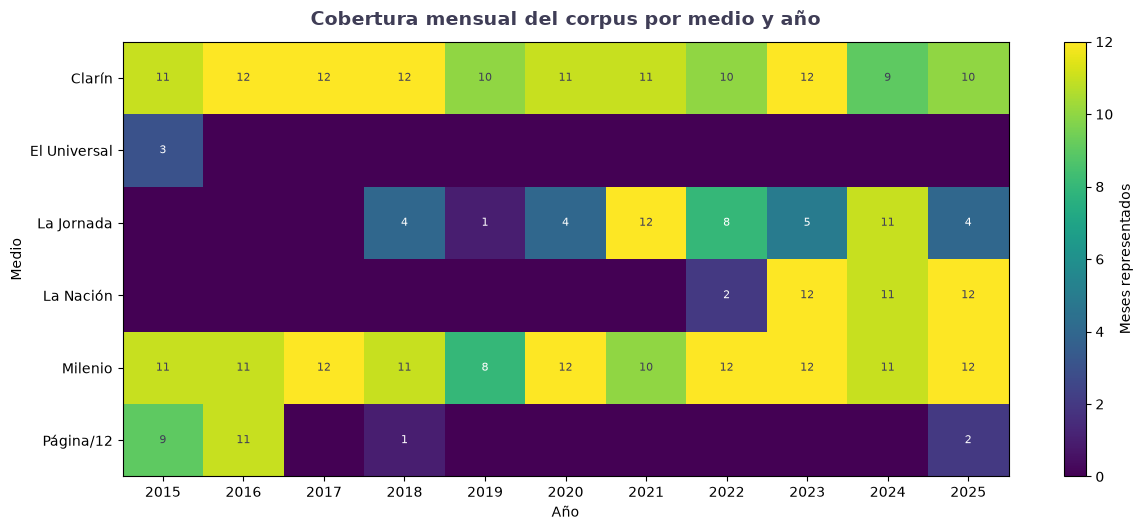

In [20]:
# ============================================================
# Cobertura mensual del corpus por medio y año
# ============================================================

monthly_coverage = analysis_corpus.copy()

# ------------------------------------------------------------
# Obtener mes de la captura
# ------------------------------------------------------------

monthly_coverage["snapshot_datetime"] = pd.to_datetime(
    monthly_coverage["snapshot_datetime"],
    errors="coerce",
)

monthly_coverage["snapshot_month"] = (
    monthly_coverage["snapshot_datetime"]
    .dt.month
)

# ------------------------------------------------------------
# Número de meses distintos representados por medio y año
# ------------------------------------------------------------

months_by_source_year = (
    monthly_coverage
    .dropna(
        subset=[
            "snapshot_month",
            "analysis_year",
        ]
    )
    .groupby(
        [
            "country",
            "newspaper",
            "analysis_year",
        ],
        as_index=False,
    )
    .agg(
        Meses_representados=(
            "snapshot_month",
            "nunique",
        )
    )
)

# ------------------------------------------------------------
# Matriz medio × año
# ------------------------------------------------------------

months_table = (
    months_by_source_year
    .pivot_table(
        index="newspaper",
        columns="analysis_year",
        values="Meses_representados",
        aggfunc="max",
        fill_value=0,
    )
    .reindex(
        columns=range(
            START_YEAR,
            END_YEAR + 1,
        ),
        fill_value=0,
    )
    .astype(int)
)

display(months_table)

save_table(
    months_table,
    "06_matriz_meses_representados_medio_anio.csv",
)


# ============================================================
# Heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(12.5, 5.4)
)

matrix = months_table.to_numpy(
    dtype=float
)

im = ax.imshow(
    matrix,
    aspect="auto",
    vmin=0,
    vmax=12,
)

ax.set_title(
    "Cobertura mensual del corpus por medio y año",
    fontsize=14,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_xlabel("Año")
ax.set_ylabel("Medio")

ax.set_xticks(
    np.arange(
        len(months_table.columns)
    )
)

ax.set_xticklabels(
    months_table.columns
)

ax.set_yticks(
    np.arange(
        len(months_table.index)
    )
)

ax.set_yticklabels(
    months_table.index
)


# ------------------------------------------------------------
# Valores dentro de las celdas
# ------------------------------------------------------------

# ------------------------------------------------------------
# Valores dentro de las celdas
# Color del texto según luminosidad del fondo
# ------------------------------------------------------------

cmap = im.get_cmap()
norm = im.norm

for i in range(len(months_table.index)):
    for j in range(len(months_table.columns)):

        value = months_table.iloc[i, j]

        if value > 0:

            # Color RGB correspondiente al valor de la celda
            r, g, b, _ = cmap(norm(value))

            # Luminosidad perceptual aproximada
            luminance = (
                0.299 * r
                + 0.587 * g
                + 0.114 * b
            )

            text_color = (
                COLORS["text"]
                if luminance > 0.55
                else "white"
            )

            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=8,
                fontweight="medium",
                color=text_color,
            )


# ------------------------------------------------------------
# Barra de color
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    "Meses representados"
)

cbar.set_ticks(
    range(0, 13, 2)
)

fig.tight_layout()

save_figure(
    fig,
    "08_heatmap_meses_representados_medio_anio.png",
)

plt.show()

## 6. Características textuales y documentales

### 6.1 Procedencia del año analítico

,Origen,Documentos,Porcentaje
0,Año de archivo,2400,70.20
1,Fecha identificada en la URL,1019,29.80


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\06_origen_anio_analitico.csv
Figura: outputs\reports\figures\03_caracterizacion_corpus_final\08_origen_anio_analitico.png


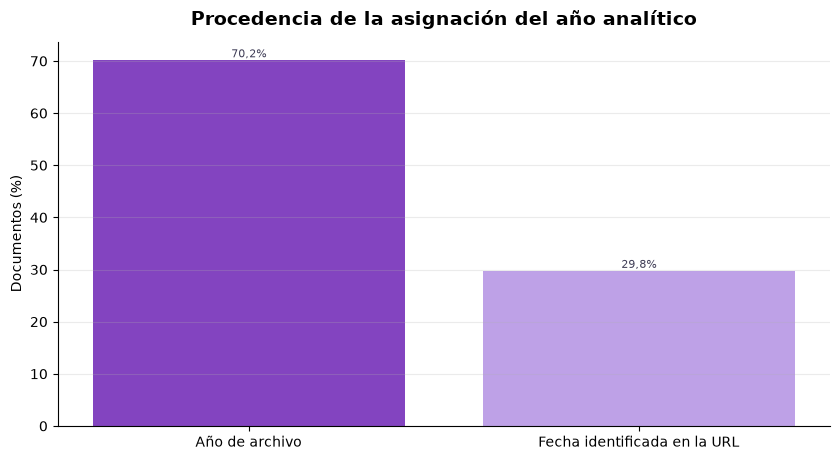

In [21]:
ys = analysis_corpus["analysis_year_source"].value_counts(
    dropna=False).rename_axis("Origen").reset_index(name="Documentos")
ys["Porcentaje"] = 100*ys["Documentos"]/len(analysis_corpus)
ys["Origen"] = ys["Origen"].replace(
    {"url_date": "Fecha identificada en la URL", "archive_year": "Año de archivo"})
display(ys)
save_table(ys.set_index("Origen"), "06_origen_anio_analitico.csv")

fig, ax = plt.subplots(figsize=(8.5, 4.7))
bars = ax.bar(ys["Origen"], ys["Porcentaje"], color=[
              COLORS["violet_500"], COLORS["violet_300"]])
label_bars(ax, bars, pct=True)
ax.set_title("Procedencia de la asignación del año analítico",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Documentos (%)")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "08_origen_anio_analitico.png")
plt.show()

### 6.2. Calidad del texto: longitud

#### 6.2.1 Distribución general

,count,mean,std,min,25%,50%,75%,90%,95%,max
Caracteres del texto analítico,"3,419.00","3,472.47","2,768.94",210.00,"2,065.00","2,799.00","4,096.50","5,955.40","7,454.00","58,715.00"
Palabras,"3,419.00",582.69,468.24,34.00,342.00,468.00,690.50,"1,001.80","1,265.40","10,065.00"
Palabras del título,"3,419.00",8.16,7.58,0.00,0.00,7.00,14.00,18.00,21.00,29.00


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\09_resumen_caracteristicas_textuales.csv
Figura: outputs\reports\figures\03_caracterizacion_corpus_final\11_distribucion_longitud_articulos.png


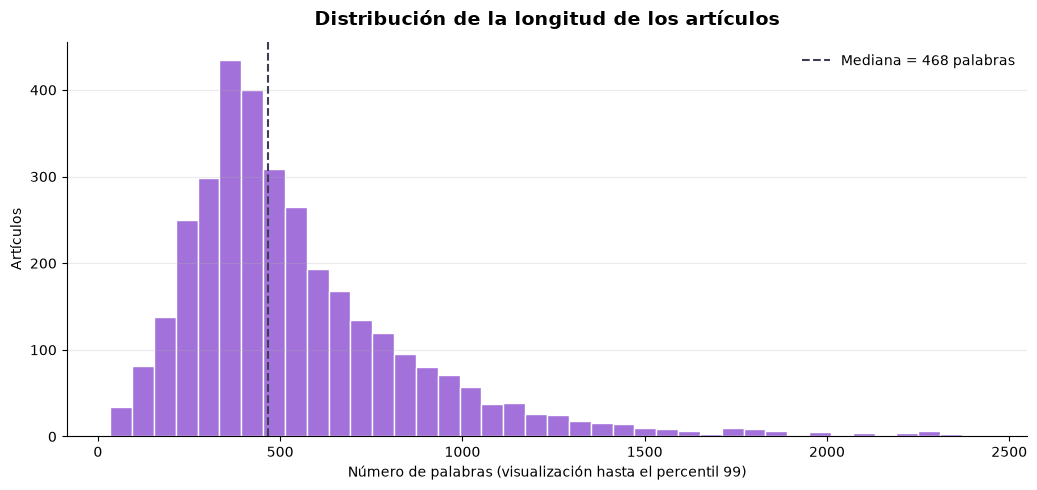

In [22]:
textual = analysis_corpus[["analysis_text_length", "word_count", "title_word_count"]].describe(
    percentiles=[.25, .5, .75, .9, .95]).T
textual = textual.rename(index={"analysis_text_length": "Caracteres del texto analítico",
                         "word_count": "Palabras", "title_word_count": "Palabras del título"})
display(textual.round(2))
save_table(textual, "09_resumen_caracteristicas_textuales.csv")

words = analysis_corpus["word_count"].dropna().astype(float)
upper = words.quantile(.99)
vals = words[words <= upper]
fig, ax = plt.subplots(figsize=(10.5, 5))
ax.hist(vals, bins=40, color=COLORS["violet_400"], edgecolor="white")
med = words.median()
ax.axvline(med, linestyle="--", linewidth=1.5,
           color=COLORS["text"], label=f"Mediana = {fmt_int(med)} palabras")
ax.set_title("Distribución de la longitud de los artículos",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Número de palabras (visualización hasta el percentil 99)")
ax.set_ylabel("Artículos")
ax.legend(frameon=False)
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "11_distribucion_longitud_articulos.png")
plt.show()

#### 6.2.2 Mediana de palabras por artículo y medio

,country,newspaper,Mediana_palabras,Documentos
0,Argentina,Página/12,776.50,170
1,Argentina,La Nación,754.00,363
2,Argentina,Clarín,575.00,667
3,México,Milenio,427.00,1198
4,México,La Jornada,383.00,1017
5,México,El Universal,370.50,4


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\09_mediana_palabras_por_medio.csv
Figura: outputs\reports\figures\03_caracterizacion_corpus_final\09_mediana_palabras_por_medio.png


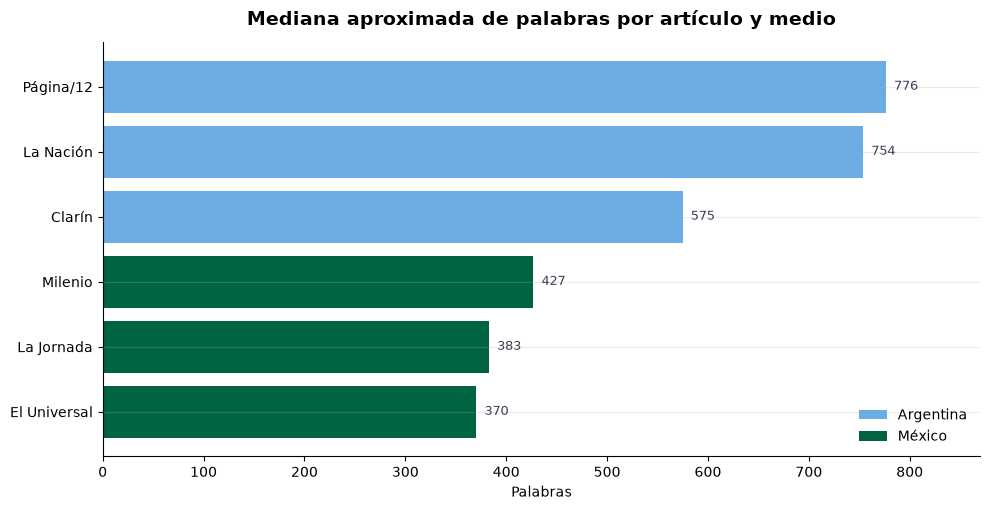

In [23]:
# ------------------------------------------------------------
# Mediana aproximada de palabras por artículo y medio
# ------------------------------------------------------------

from matplotlib.patches import Patch
word_length_by_source = (
    analysis_corpus
    .groupby(
        ["country", "newspaper"],
        as_index=False,
    )
    .agg(
        Mediana_palabras=("word_count", "median"),
        Documentos=("analysis_identity", "nunique"),
    )
    .sort_values(
        "Mediana_palabras",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(word_length_by_source)

save_table(
    word_length_by_source,
    "09_mediana_palabras_por_medio.csv",
)

# Colores según país
bar_colors = [
    (
        COLORS["argentina"]
        if country == "Argentina"
        else COLORS["mexico_dark"]
    )
    for country in word_length_by_source["country"]
]

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.2)
)

bars = ax.barh(
    word_length_by_source["newspaper"],
    word_length_by_source["Mediana_palabras"],
    color=bar_colors,
)

# Mayor mediana arriba
ax.invert_yaxis()

# Etiquetas al final de las barras
for bar, value in zip(
    bars,
    word_length_by_source["Mediana_palabras"],
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {fmt_int(value)}",
        va="center",
        ha="left",
        fontsize=9,
        color=TEXT_COLOR,
    )

ax.set_title(
    "Mediana aproximada de palabras por artículo y medio",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("Palabras")
ax.set_ylabel("")

clean_axes(
    ax,
)

# Espacio para las etiquetas
ax.set_xlim(
    0,
    word_length_by_source["Mediana_palabras"].max() * 1.12,
)

# Leyenda por país

legend_handles = [
    Patch(
        facecolor=COLORS["argentina"],
        label="Argentina",
    ),
    Patch(
        facecolor=COLORS["mexico_dark"],
        label="México",
    ),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

save_figure(
    fig,
    "09_mediana_palabras_por_medio.png",
)

plt.show()

## 7. Síntesis del corpus

In [24]:
# ============================================================
# Resumen final del corpus
# ============================================================

summary = pd.DataFrame({
    "Indicador": [
        "Corpus principal seleccionado",
        "Corpus analítico consolidado",
        "Corpus final elegible para análisis",
        "Países",
        "Medios",
        "Años",
        "Periodo",
        "Documentos de Argentina",
        "Documentos de México",
    ],
    "Valor": [
        len(main_cases),
        len(articles_all),
        len(analysis_corpus),
        analysis_corpus["country"].nunique(),
        analysis_corpus["newspaper"].nunique(),
        analysis_corpus["analysis_year"].nunique(),
        (
            f"{int(analysis_corpus['analysis_year'].min())}"
            f"–{int(analysis_corpus['analysis_year'].max())}"
        ),
        int(
            analysis_corpus["country"]
            .eq("Argentina")
            .sum()
        ),
        int(
            analysis_corpus["country"]
            .eq("México")
            .sum()
        ),
    ],
})

display(summary)

save_table(
    summary,
    "10_resumen_corpus_final.csv",
)

,Indicador,Valor
0,Corpus principal seleccionado,3548
1,Corpus analítico consolidado,3497
2,Corpus final elegible para análisis,3419
3,Países,2
4,Medios,6
5,Años,11
6,Periodo,2015–2025
7,Documentos de Argentina,1200
8,Documentos de México,2219


Tabla: outputs\reports\tables\03_caracterizacion_corpus_final\10_resumen_corpus_final.csv


## 8. Transición al análisis longitudinal y comparativo

La caracterización anterior fija el conjunto documental de referencia para el siguiente notebook. El Notebook 04 deberá partir del mismo subconjunto `analysis_eligible == True` y conservar `analysis_year`, `country`, `source/newspaper` y `gender_recognition_mode` como dimensiones estructurales.

- **OE1:** patrones léxicos y discursivos y su evolución.
- **OE2:** evolución de las formas de reconocimiento y denominación de la violencia machista.
- **OE3:** patrones compartidos entre Argentina y México y particularidades asociadas a los medios.

Dado que la cobertura es desigual entre años y fuentes, las comparaciones de intensidad relativa deberán utilizar porcentajes dentro del subconjunto correspondiente, frecuencias normalizadas u otras medidas que controlen el tamaño desigual de los grupos.

In [25]:
analysis_dimensions = ["analysis_identity", "source", "newspaper", "country", "analysis_year", "analysis_period", "analysis_year_source",
                       "analysis_title", "analysis_text", "analysis_text_length", "word_count", "gender_recognition_mode",
                       "explicit_label_type", "explicit_label_terms_json", "contextual_evidence_level", "contextual_violence_types_json"]
print("Variables disponibles para el Notebook 04:")
for c in analysis_dimensions:
    if c in analysis_corpus.columns:
        print("-", c)
print()
print(f"Corpus de referencia: {len(analysis_corpus):,} artículos")

Variables disponibles para el Notebook 04:
- analysis_identity
- source
- newspaper
- country
- analysis_year
- analysis_period
- analysis_year_source
- analysis_title
- analysis_text
- analysis_text_length
- word_count
- gender_recognition_mode
- explicit_label_type
- explicit_label_terms_json
- contextual_evidence_level
- contextual_violence_types_json

Corpus de referencia: 3,419 artículos


## Conclusión

El corpus analítico queda definido como el conjunto de documentos consolidados que cumplen los criterios de elegibilidad textual establecidos por el pipeline. La caracterización documenta su distribución por país, medio y año, la procedencia de la asignación temporal, las modalidades generales de reconocimiento y sus propiedades textuales básicas.

A partir de este punto, el análisis deja de centrarse en **cómo se construyó el corpus** y pasa a estudiar **qué patrones discursivos contiene, cómo evolucionan entre 2015 y 2025 y en qué medida difieren entre Argentina, México y los medios considerados**.